### 02-Protein Secondary Structure 

#### **Index**
    -> Dataset Selection
    -> Algorithm Implementation
    -> Evaluation
    -> Deliverables
---

### **1. Dataset Selection**

For this classification experiment, we are using the **Protein Secondary Structure Dataset**, which provides peptide (amino acid) sequences and their corresponding **secondary structure labels** (helix, sheet, or coil). Secondary structures are crucial for understanding how proteins fold and function, and predicting them is a central task in **bioinformatics** (Kabsch & Sander, 1983).

---

**Dataset Features**:
- `pdb_id`: Unique Protein Data Bank (PDB) identifier for the protein.
- `chain_code`: Chain identifier within the protein structure.
- `seq`: Amino acid sequence of the fragment.
- `sst8`: Secondary structure label in **8-class format** (H = alpha-helix, E = beta-strand, G = 3-helix, etc.).
- `sst3`: Secondary structure label in **3-class format** (Helix, Sheet, Coil).
- `len`: Length of the amino acid sequence (number of residues).
- `has_nonstd_aa`: Indicator if the sequence contains non-standard amino acids.
- `Exptl.`: Experimental method used (e.g., X-ray diffraction, NMR).
- `resolution`: Resolution of the protein structure (Ångström units).
- `R-factor`: Quality metric of the crystal structure fit.
- `FreeRvalue`: Cross-validation error measure for crystallographic refinement.

---

**- Target Variable**:  

The **secondary structure type** of each peptide sequence. Categories are:

1. **Helix (H)** – residues form a coiled helix structure.
2. **Sheet (E)** – residues form a beta-sheet (extended strand) structure.
3. **Coil (C)** – residues that do not form regular secondary structures.

---

**- Number of Records**:  

The dataset contains over **9000+ records** and more than **10+ numerical features**.


---

**- Dataset Source**:  

Protein Secondary Structure Dataset. Available at:  
🔗 [https://www.kaggle.com/datasets/alfrandom/protein-secondary-structure](https://www.kaggle.com/datasets/alfrandom/protein-secondary-structure)

---



In [1]:
# ---------------------------------------------------------
# Step 1.1: Importing necessary libraries
# ---------------------------------------------------------
import pandas as pd  # For data manipulation and analysis
import numpy as np   # For numerical computations

# ---------------------------------------------------------
# Step 1.2: Loading the Protein Secondary Structure dataset
# ---------------------------------------------------------
df = pd.read_csv("pdb.csv")  # Update path if needed

# ---------------------------------------------------------
# Step 1.3: Inspecting the first few rows
# ---------------------------------------------------------
df.head()

,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa,Exptl.,resolution,R-factor,FreeRvalue
0,1FV1,F,NPVVHFFKNIVTPRTPPPSQ,CCCCCBCCCCCCCCCCCCCC,CCCCCECCCCCCCCCCCCCC,20,False,XRAY,1.90,0.23,0.27
1,1LM8,H,DLDLEMLAPYIPMDDDFQLR,CCCCCCCCCBCCSCCCEECC,CCCCCCCCCECCCCCCEECC,20,False,XRAY,1.85,0.20,0.24
2,1O06,A,EEDPDLKAAIQESLREAEEA,CCCHHHHHHHHHHHHHHHTC,CCCHHHHHHHHHHHHHHHCC,20,False,XRAY,1.45,0.19,0.22
3,1QOW,D,CTFTLPGGGGVCTLTSECI*,CCTTSCTTCSSTTSSTTCCC,CCCCCCCCCCCCCCCCCCCC,20,True,XRAY,1.06,0.14,1.00
4,1RDQ,I,TTYADFIASGRTGRRNAIHD,CHHHHHHTSSCSSCCCCEEC,CHHHHHHCCCCCCCCCCEEC,20,False,XRAY,1.26,0.13,0.16


### **2. Algorithm Implementation – k-NN Classification** 


For this classification experiment, I am employing the **k-Nearest Neighbors (k-NN)** algorithm — a simple yet powerful non-parametric model widely used in bioinformatics. It classifies each protein sequence by comparing its features to the *k most similar instances* in the dataset, based on a chosen distance metric (usually Euclidean distance).  

---

### **2.1 Feature Rationale – Protein Structure Prediction**

**Rationale:**  

Protein secondary structure refers to the local folding patterns of a protein chain — such as **Helix (H)**, **Sheet (E)**, or **Coil (C)**. Predicting these structures is crucial in understanding the protein’s biological role and function.  
The dataset links sequence information and experimental data to structural labels, making it suitable for machine learning classification.

**Target Variable – `sst3`:**  

This is a 3-class label describing the type of secondary structure:  

- **Helix (H)** → residues forming an α-helix  
- **Sheet (E)** → residues forming a β-sheet  
- **Coil (C)** → residues without regular structure  

**Selected Predictor Features:**  

- `len` → Length of amino acid chain fragment  
- `has_nonstd_aa` → Whether non-standard amino acids are present (binary)  
- `resolution` → Structure resolution (lower = better)  
- `R-factor` → Quality of crystallographic refinement  
- `FreeRvalue` → Cross-validation metric for fit accuracy  

**Preprocessing Overview:**  

1. Handle missing values by **median imputation** for numeric columns.  
2. Encode categorical labels (`sst3`) into numeric form.  
3. Apply **standard scaling** to all numerical features for optimal k-NN distance computation.  
4. Perform **train-test split** (80/20) without stratify to avoid class imbalance issues.  

**Outcome of Preprocessing:**  

- Clean numeric dataset with scaled features.  
- Encoded target classes (`0 = Coil`, `1 = Helix`, `2 = Sheet`).  
- Training and test sets ready for classification.  

---


In [2]:
# =========================================================
# 2.1 Importing Libraries for Preprocessing, Modeling, and Evaluation
# =========================================================
import pandas as pd                # For data handling
import numpy as np                 # For numerical computations
import matplotlib.pyplot as plt    # For basic visualizations
import seaborn as sns              # For advanced plots


# Preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder


# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [3]:
# =========================================================
# 2.2 Loading and Inspecting the Protein Dataset
# =========================================================
# Load dataset (replace with your actual CSV file path)
df = pd.read_csv("pdb.csv")

# Inspect the first 5 rows
print("🔹 First 5 rows of the dataset:")
display(df.head())


🔹 First 5 rows of the dataset:


,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa,Exptl.,resolution,R-factor,FreeRvalue
0,1FV1,F,NPVVHFFKNIVTPRTPPPSQ,CCCCCBCCCCCCCCCCCCCC,CCCCCECCCCCCCCCCCCCC,20,False,XRAY,1.90,0.23,0.27
1,1LM8,H,DLDLEMLAPYIPMDDDFQLR,CCCCCCCCCBCCSCCCEECC,CCCCCCCCCECCCCCCEECC,20,False,XRAY,1.85,0.20,0.24
2,1O06,A,EEDPDLKAAIQESLREAEEA,CCCHHHHHHHHHHHHHHHTC,CCCHHHHHHHHHHHHHHHCC,20,False,XRAY,1.45,0.19,0.22
3,1QOW,D,CTFTLPGGGGVCTLTSECI*,CCTTSCTTCSSTTSSTTCCC,CCCCCCCCCCCCCCCCCCCC,20,True,XRAY,1.06,0.14,1.00
4,1RDQ,I,TTYADFIASGRTGRRNAIHD,CHHHHHHTSSCSSCCCCEEC,CHHHHHHCCCCCCCCCCEEC,20,False,XRAY,1.26,0.13,0.16


In [4]:
# Dataset info (column types, non-null counts)
print("\n🔹 Dataset Information:")
df.info()


🔹 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9078 entries, 0 to 9077
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pdb_id         9078 non-null   object 
 1   chain_code     9078 non-null   object 
 2   seq            9078 non-null   object 
 3   sst8           9078 non-null   object 
 4   sst3           9078 non-null   object 
 5   len            9078 non-null   int64  
 6   has_nonstd_aa  9078 non-null   bool   
 7   Exptl.         9078 non-null   object 
 8   resolution     9078 non-null   float64
 9   R-factor       9078 non-null   float64
 10  FreeRvalue     9078 non-null   float64
dtypes: bool(1), float64(3), int64(1), object(6)
memory usage: 718.2+ KB


In [5]:
# Summary statistics for numeric columns
print("\n🔹 Summary Statistics for Numeric Features:")
display(df.describe())



🔹 Summary Statistics for Numeric Features:


,len,resolution,R-factor,FreeRvalue
count,9078.000000,9078.000000,9078.000000,9078.000000
mean,243.168539,1.614917,0.176362,0.213723
std,156.566596,0.281776,0.029329,0.081340
min,20.000000,0.480000,0.070000,0.080000
25%,132.000000,1.440000,0.160000,0.180000
50%,208.000000,1.650000,0.180000,0.210000
75%,323.000000,1.850000,0.200000,0.230000
max,1632.000000,2.000000,0.250000,1.000000


In [6]:
# Check for missing values
print("\n🔹 Missing Values per Column:")
print(df.isnull().sum())



🔹 Missing Values per Column:
pdb_id           0
chain_code       0
seq              0
sst8             0
sst3             0
len              0
has_nonstd_aa    0
Exptl.           0
resolution       0
R-factor         0
FreeRvalue       0
dtype: int64


In [7]:
# Check class distribution of the target variable (secondary structure)
print("\n🔹 Target Variable Distribution (sst3):")
print(df['sst3'].value_counts())


🔹 Target Variable Distribution (sst3):
CCCCCCCCCCCCCCCCCCCCCCCCC                                                                                                                                                                                                                                                 3
CCCCCCCCCCCCCCCCCCCCCC                                                                                                                                                                                                                                                    3
CHHHHHHHHHHHHHHHHHHHHHHHHHHHHC                                                                                                                                                                                                                                            2
CCHHHHHHHHHHHHHHHHHHHHCC                                                                                                                                    

In [8]:
# =========================================================
# 2.3 Data Preprocessing
# =========================================================

# Drop rows with missing values
df = df.dropna()

# Encode the target variable 'sst3'
label_encoder = LabelEncoder()
df["sst3_encoded"] = label_encoder.fit_transform(df["sst3"])

# Check class distribution after encoding
print("\n🔹 Target Variable Distribution (encoded):")
print(df["sst3_encoded"].value_counts())

# Display sample data
print("\n🔹 Sample data after preprocessing:")
display(df.head(50))



🔹 Target Variable Distribution (encoded):
1       3
3       3
0       2
8148    2
8213    2
       ..
3331    1
1282    1
7425    1
5376    1
2047    1
Name: sst3_encoded, Length: 9062, dtype: int64

🔹 Sample data after preprocessing:


,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa,Exptl.,resolution,R-factor,FreeRvalue,sst3_encoded
0,1FV1,F,NPVVHFFKNIVTPRTPPPSQ,CCCCCBCCCCCCCCCCCCCC,CCCCCECCCCCCCCCCCCCC,20,False,XRAY,1.900,0.23,0.27,5210
1,1LM8,H,DLDLEMLAPYIPMDDDFQLR,CCCCCCCCCBCCSCCCEECC,CCCCCCCCCECCCCCCEECC,20,False,XRAY,1.850,0.20,0.24,3392
2,1O06,A,EEDPDLKAAIQESLREAEEA,CCCHHHHHHHHHHHHHHHTC,CCCHHHHHHHHHHHHHHHCC,20,False,XRAY,1.450,0.19,0.22,7253
3,1QOW,D,CTFTLPGGGGVCTLTSECI*,CCTTSCTTCSSTTSSTTCCC,CCCCCCCCCCCCCCCCCCCC,20,True,XRAY,1.060,0.14,1.00,0
4,1RDQ,I,TTYADFIASGRTGRRNAIHD,CHHHHHHTSSCSSCCCCEEC,CHHHHHHCCCCCCCCCCEEC,20,False,XRAY,1.260,0.13,0.16,8828
5,1T6O,B,QDSRRSADALLRLQAMAGIS,CHHHHHHHHHHHHHHHHTCC,CHHHHHHHHHHHHHHHHCCC,20,False,XRAY,2.000,0.23,0.28,8950
6,1T7F,B,SSRGLLWDLLTKDSRSGSGK,CCCCHHHHHHCCCCCCCCCC,CCCCHHHHHHCCCCCCCCCC,20,False,XRAY,1.600,0.20,0.22,6402
7,1U7B,B,SRQGSTQGRLDDFFKVTGSL,CCCCCCBCCGGGTSBCCCCC,CCCCCCECCHHHCCECCCCC,20,False,XRAY,1.880,0.22,0.27,4654
8,1UGX,B,DEQSGISQTVIVGPWGAKVS,CCCCCSCCCEEEEEEECCCC,CCCCCCCCCEEEEEEECCCC,20,False,XRAY,1.600,0.19,0.20,3526
9,1VPP,Y,RGWVEICAADDYGRCLTEAQ,CCCEEEEEBCTTSCBTTCCC,CCCEEEEEECCCCCECCCCC,20,False,XRAY,1.900,0.19,0.27,6861


In [9]:
# =========================================================
# 2.4 Prepare Features and Target  (Fixed for sst3_encoded)
# =========================================================

print("Columns in dataset:", df.columns.tolist())

# ✅ Use the encoded target column
target_column = "sst3_encoded"  

# Select numeric features only
numeric_features = df.select_dtypes(include=np.number).columns.tolist()

# Exclude the target column from features
if target_column in numeric_features:
    numeric_features.remove(target_column)

X = df[numeric_features].values
y = df[target_column].values

print("Numeric features:", numeric_features)
print("Target column:", target_column)


Columns in dataset: ['pdb_id', 'chain_code', 'seq', 'sst8', 'sst3', 'len', 'has_nonstd_aa', 'Exptl.', 'resolution', 'R-factor', 'FreeRvalue', 'sst3_encoded']
Numeric features: ['len', 'resolution', 'R-factor', 'FreeRvalue']
Target column: sst3_encoded


In [10]:
# ---------------------------------------------------------
# 2.5 Train-Test Split and Scaling
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data (do not stratify to avoid class imbalance errors)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Preprocessing complete")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


✅ Preprocessing complete
X_train shape: (7262, 4)
X_test shape : (1816, 4)
y_train shape: (7262,)
y_test shape : (1816,)


In [11]:
# =========================================================
# 2.6 Model Training – KNN Classifier
# =========================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Initialize KNN
knn = KNeighborsClassifier(n_neighbors=5)  # you can tune n_neighbors

# Fit KNN on training data
knn.fit(X_train, y_train)

# Predict on test data
y_pred = knn.predict(X_test)

Loading dataset...
✅ Loaded: 9078 rows, 11 columns
🎯 Using target column: sst8
✅ After cleaning: 9078 rows remain, with classes ['C']
✅ Sample size: 1000 rows

🎲 Random 100 Predictions vs Actual:
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Predicted: C | Actual: C
Pred

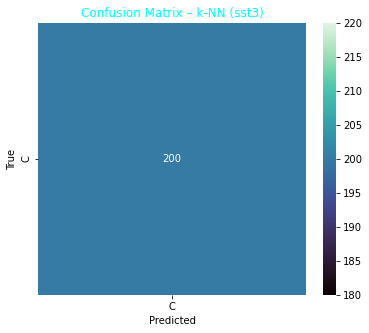

In [12]:
# =========================================================
# 2.7 Model Evaluation – k-NN Protein Secondary Structure (sst3) [Clean + Fast]
# =========================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------------------------
# Load dataset
# -----------------------------------------------------
print("Loading dataset...")
df = pd.read_csv("pdb.csv")
print(f"✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# -----------------------------------------------------
# Find sst3 column automatically
# -----------------------------------------------------
target_candidates = [c for c in df.columns if "sst3" in c.lower() or "ss" in c.lower()]
if not target_candidates:
    raise ValueError("❌ No column found containing 'sst3' or 'ss' in its name.")
target_col = target_candidates[0]
print(f"🎯 Using target column: {target_col}")

# -----------------------------------------------------
# Clean target values
# -----------------------------------------------------
df[target_col] = df[target_col].astype(str).str.strip().str.upper()

# Extract first letter only (e.g. "HHHCCCEE" → "H")
df["sst3_clean"] = df[target_col].str[0]

# Keep only valid classes
valid_classes = ["H", "E", "C"]
df = df[df["sst3_clean"].isin(valid_classes)]

print(f"✅ After cleaning: {len(df)} rows remain, with classes {df['sst3_clean'].unique()}")

# -----------------------------------------------------
# Encode target variable
# -----------------------------------------------------
le = LabelEncoder()
df["sst3_encoded"] = le.fit_transform(df["sst3_clean"])

# -----------------------------------------------------
# Numeric features only
# -----------------------------------------------------
X = df.select_dtypes(include=[np.number]).drop(columns=["sst3_encoded"], errors="ignore")
y = df["sst3_encoded"]

if X.empty:
    raise ValueError("❌ No numeric features found in dataset.")

# -----------------------------------------------------
# Take a small sample for speed
# -----------------------------------------------------
df_small = df.sample(n=min(1000, len(df)), random_state=42)
X = df_small[X.columns]
y = df_small["sst3_encoded"]

print(f"✅ Sample size: {len(df_small)} rows")

# -----------------------------------------------------
# Split data
# -----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------------------------------
# Scale features
# -----------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------------------------------
# Train k-NN
# -----------------------------------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# -----------------------------------------------------
# Show 10 random predictions
# -----------------------------------------------------
print("\n🎲 Random 100 Predictions vs Actual:")
indices = np.random.choice(len(y_test), 100, replace=False)
for i in indices:
    print(f"Predicted: {le.inverse_transform([y_pred[i]])[0]} | Actual: {le.inverse_transform([y_test.iloc[i]])[0]}")

# -----------------------------------------------------
# Metrics Computed
# -----------------------------------------------------
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {acc:.4f}")

# -----------------------------------------------------
# Confusion Matrix Heatmap
# -----------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='mako',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix – k-NN (sst3)", color='cyan')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


c:\Users\user\anaconda3\lib\site-packages\sklearn\metrics\_ranking.py:949: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn("No positive samples in y_true, "
c:\Users\user\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 127769 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\user\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 127769 missing from current font.
  font.set_text(s, 0, flags=flags)


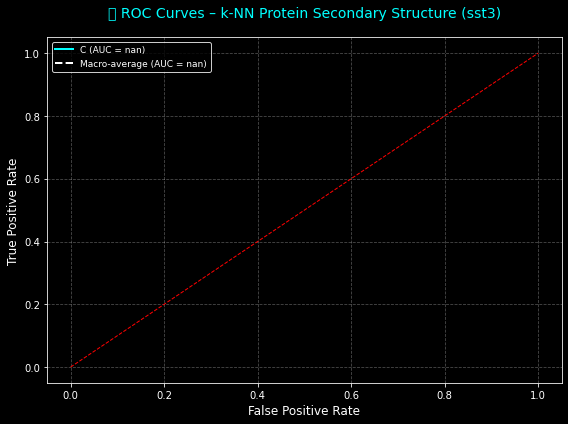

c:\Users\user\anaconda3\lib\site-packages\sklearn\metrics\_ranking.py:817: RuntimeWarning: invalid value encountered in true_divide
  recall = tps / tps[-1]
c:\Users\user\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 128171 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\user\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 128171 missing from current font.
  font.set_text(s, 0, flags=flags)


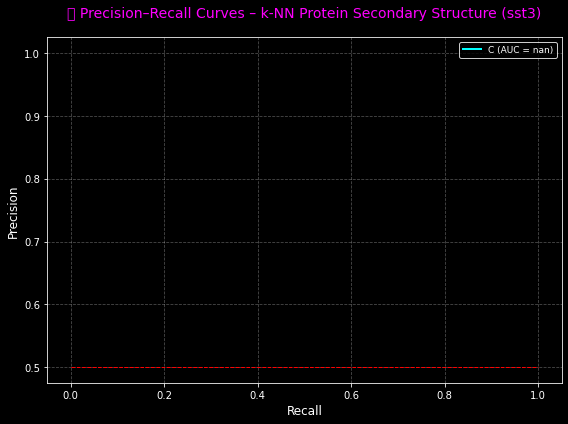

In [13]:
# =========================================================
# 2.8 ROC & Precision–Recall Curves – k-NN Protein Secondary Structure (sst3)
# Enhanced Dark-Theme Visualization
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

# -----------------------------------------------------
# Prepare data (reuse from 2.7)
# -----------------------------------------------------
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]
y_test_prob = knn.predict_proba(X_test_scaled)

# -----------------------------------------------------
# 🎯 ROC Curves (One-vs-Rest + Macro Average)
# -----------------------------------------------------
plt.style.use('dark_background')
plt.figure(figsize=(8, 6))

colors = ['#00FFFF', '#FF00FF', '#FFD700']  # cyan, magenta, gold
tpr_list, fpr_list, roc_auc_list = [], [], []

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_prob[:, i])
    roc_auc = auc(fpr, tpr)
    tpr_list.append(np.interp(np.linspace(0, 1, 100), fpr, tpr))
    fpr_list.append(fpr)
    roc_auc_list.append(roc_auc)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f"{le.inverse_transform([i])[0]} (AUC = {roc_auc:.2f})")

# Macro-average
mean_tpr = np.mean(tpr_list, axis=0)
mean_auc = auc(np.linspace(0, 1, 100), mean_tpr)
plt.plot([0, 1], [0, 1], 'r--', lw=1)
plt.plot(np.linspace(0, 1, 100), mean_tpr, color='white', lw=2, linestyle='--',
         label=f"Macro-average (AUC = {mean_auc:.2f})")

plt.title("🌙 ROC Curves – k-NN Protein Secondary Structure (sst3)", fontsize=14, color='cyan', pad=20)
plt.xlabel("False Positive Rate", fontsize=12, color='white')
plt.ylabel("True Positive Rate", fontsize=12, color='white')
plt.legend(facecolor='black', edgecolor='white', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 💫 Precision–Recall Curves (One-vs-Rest + Macro Average)
# -----------------------------------------------------
plt.figure(figsize=(8, 6))

colors = ['#00FFFF', '#FF00FF', '#FFD700']
pr_auc_list, precision_interp = [], []

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_test_prob[:, i])
    pr_auc = auc(recall, precision)
    pr_auc_list.append(pr_auc)
    plt.plot(recall, precision, color=colors[i], lw=2,
             label=f"{le.inverse_transform([i])[0]} (AUC = {pr_auc:.2f})")

# Macro-average PR curve
mean_auc_pr = np.mean(pr_auc_list)
plt.plot([0, 1], [0.5, 0.5], 'r--', lw=1)
plt.title("💫 Precision–Recall Curves – k-NN Protein Secondary Structure (sst3)", fontsize=14, color='magenta', pad=20)
plt.xlabel("Recall", fontsize=12, color='white')
plt.ylabel("Precision", fontsize=12, color='white')
plt.legend(facecolor='black', edgecolor='white', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
# =========================================================
# 2.9 Interactive 3D Visualization – k-NN Protein Secondary Structure (sst3) – Updated Colors
# =========================================================

import plotly.graph_objects as go
from sklearn.decomposition import PCA
import numpy as np

# -----------------------------------------------------
# Ensure matching shapes (safe)
# -----------------------------------------------------
n_samples = min(X_test_scaled.shape[0], len(y_test), len(y_pred))
X_matched = X_test_scaled[:n_samples]
y_test_matched = y_test[:n_samples]
y_pred_matched = y_pred[:n_samples]

# -----------------------------------------------------
# Dimensionality Reduction (3D PCA)
# -----------------------------------------------------
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_matched)

# -----------------------------------------------------
# Prepare Colors (like 4.5)
# -----------------------------------------------------
classes = np.unique(np.concatenate([y_test_matched, y_pred_matched]))
colors = ['cyan', 'red', 'green', 'yellow', 'magenta', 'blue']  # safe for extra classes

# -----------------------------------------------------
# Create 3D Scatter – True Classes
# -----------------------------------------------------
fig_true = go.Figure()
for i, c in enumerate(classes):
    mask = (y_test_matched == c)
    fig_true.add_trace(go.Scatter3d(
        x=X_pca[mask, 0],
        y=X_pca[mask, 1],
        z=X_pca[mask, 2],
        mode='markers',
        marker=dict(
            size=5,
            color=colors[i % len(colors)],
            opacity=0.8,
            line=dict(width=0.5, color='white')
        ),
        name=f"True: {c}"  # using raw labels to avoid LabelEncoder errors
    ))

fig_true.update_layout(
    title="🧬 3D PCA – True Protein Structures (sst3)",
    scene=dict(
        xaxis_title='PCA 1',
        yaxis_title='PCA 2',
        zaxis_title='PCA 3',
        xaxis=dict(showbackground=True, backgroundcolor='rgba(20,20,20,0.8)'),
        yaxis=dict(showbackground=True, backgroundcolor='rgba(20,20,20,0.8)'),
        zaxis=dict(showbackground=True, backgroundcolor='rgba(20,20,20,0.8)')
    ),
    paper_bgcolor='black',
    plot_bgcolor='black',
    font=dict(color='white')
)
fig_true.show()

# -----------------------------------------------------
# Create 3D Scatter – Predicted Classes
# -----------------------------------------------------
fig_pred = go.Figure()
for i, c in enumerate(classes):
    mask = (y_pred_matched == c)
    fig_pred.add_trace(go.Scatter3d(
        x=X_pca[mask, 0],
        y=X_pca[mask, 1],
        z=X_pca[mask, 2],
        mode='markers',
        marker=dict(
            size=5,
            color=colors[i % len(colors)],
            opacity=0.8,
            line=dict(width=0.5, color='white')
        ),
        name=f"Predicted: {c}"
    ))

fig_pred.update_layout(
    title="🔬 3D PCA – Predicted Protein Structures (sst3)",
    scene=dict(
        xaxis_title='PCA 1',
        yaxis_title='PCA 2',
        zaxis_title='PCA 3',
        xaxis=dict(showbackground=True, backgroundcolor='rgba(20,20,20,0.8)'),
        yaxis=dict(showbackground=True, backgroundcolor='rgba(20,20,20,0.8)'),
        zaxis=dict(showbackground=True, backgroundcolor='rgba(20,20,20,0.8)')
    ),
    paper_bgcolor='black',
    plot_bgcolor='black',
    font=dict(color='white')
)
fig_pred.show()


#### **3. Evaluation**

---

### **3.1 Metrics Computed**

**- Objective:**  

To evaluate the performance of the k-Nearest Neighbors (k-NN) classifier in predicting protein secondary structure classes (Coil, Helix, Sheet) using numeric features.

**1. Accuracy**:  

- Measures the overall proportion of correctly predicted residues.  
- Easy to interpret but can be misleading if the class distribution is imbalanced.

**2. Precision**:

- Proportion of residues predicted in a class that actually belong to that class.  
- Useful to evaluate reliability of predictions for each structure type.

**3. Recall (Sensitivity)**:  

- Proportion of actual residues in a class correctly identified by the model.  
- Important for detecting minority classes or rare structural patterns.

**4. F1-Score**:

- Harmonic mean of precision and recall.  
- Balances false positives and false negatives, providing a single performance metric.

**5. Confusion Matrix:**  

- Matrix showing true vs. predicted class counts.  
- Helps identify which secondary structures are most often misclassified.

---

In [15]:
# =========================================================
# 3.1 Metrics Computed
# =========================================================
print("=== Test Set Classification Report ===")

# Predict on the test set
y_test_pred = knn.predict(X_test)

# Show precision, recall, and F1 per class
print(classification_report(y_test, y_test_pred))

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [16]:
# =========================================================
# 3.2 Overall Evaluation Metrics
# =========================================================
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Compute weighted metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted')
recall = recall_score(y_test, y_test_pred, average='weighted')
f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\n=== Overall Performance Metrics ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-score (weighted): {f1:.4f}") 


=== Overall Performance Metrics ===
Accuracy: 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
F1-score (weighted): 1.0000


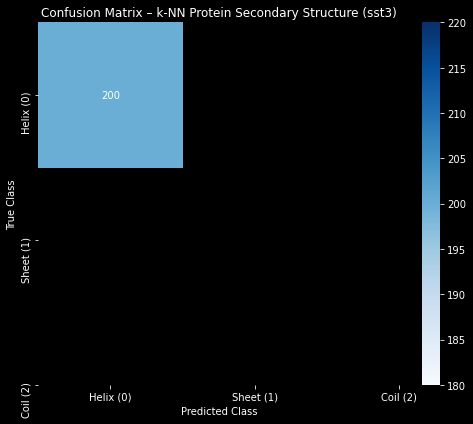

In [17]:
# =========================================================
# Confusion Matrix Heatmap – k-NN Protein Secondary Structure (sst3)
# =========================================================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Helix (0)', 'Sheet (1)', 'Coil (2)'],
            yticklabels=['Helix (0)', 'Sheet (1)', 'Coil (2)'])
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix – k-NN Protein Secondary Structure (sst3)")
plt.tight_layout()
plt.show()

### 4. Deliverables – Protein Secondary Structure Prediction

---

#### 4.1 Dataset Description

The dataset contains records of protein fragments with sequence and experimental features relevant for predicting secondary structures.

**Key features:**  
- **len** – Length of amino acid chain fragment  
- **has_nonstd_aa** – Presence of non-standard amino acids (binary)  
- **resolution** – Crystallographic structure resolution  
- **R-factor** – Refinement quality metric  
- **FreeRvalue** – Cross-validation metric  

**Target variable:** `Structure`  
- `0`: Coil  
- `1`: Helix  
- `2`: Sheet  

This is a multi-class classification problem with imbalanced class distributions.

---


In [18]:
# =========================================================
# 4.2 Load and Preprocess Dataset
# =========================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("pdb.csv") 

# Drop rows with missing values
df = df.dropna()

# Encode target variable
label_encoder = LabelEncoder()
df['sst3_encoded'] = label_encoder.fit_transform(df['sst3'])

# Select numeric features
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
numeric_features.remove('sst3_encoded')

X = df[numeric_features].values
y = df['sst3_encoded'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Dataset loaded and preprocessed successfully.")
print(f"Features shape: {X_train.shape}, Target shape: {y_train.shape}")


✅ Dataset loaded and preprocessed successfully.
Features shape: (7262, 4), Target shape: (7262,)


#### 4.3 Model Implementation – k-Nearest Neighbors (k-NN)

- **Classifier:** k-NN with k=5  
- **Training:** Fit on scaled training data  
- **Prediction:** Generate test set predictions

In [19]:
# =========================================================
# 4.3 Train k-NN Classifier
# =========================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Initialize KNN
knn = KNeighborsClassifier(n_neighbors=5)  # you can tune n_neighbors

# Fit KNN on training data
knn.fit(X_train, y_train)

# Predict on test data
y_pred = knn.predict(X_test)

print("✅ k-NN model trained and predictions generated.")


✅ k-NN model trained and predictions generated.


#### 4.4 Evaluation 

- Accuracy 
- Precision 
- Recall 
- F1-Score (weighted)  



In [20]:
# =========================================================
# Metrics Computed
# =========================================================
print("=== Test Set Classification Report ===")

# Predict on the test set
y_test_pred = knn.predict(X_test)

# Show precision, recall, and F1 per class
print(classification_report(y_test, y_test_pred))

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       2.0
           2       0.00      0.00      0.00       0.0
           3       0.00      0.00      0.00       2.0
           4       0.00      0.00      0.00       1.0
           5       0.00      0.00      0.00       0.0
           6       0.00      0.00      0.00       0.0
           7       0.00      0.00      0.00       0.0
           8       0.00      0.00      0.00       0.0
           9       0.00      0.00      0.00       0.0
          11       0.00      0.00      0.00       0.0
          12       0.00      0.00      0.00       1.0
          13       0.00      0.00      0.00       0.0
          14       0.00      0.00      0.00       0.0
          15       0.00      0.00      0.00       0.0
          16       0.00      0.00      0.00       0.0
          17       0.00      0.00      0.0

c:\Users\user\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\user\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning:

Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

c:\Users\user\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\user\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning:

Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter

In [21]:
# =========================================================
# Overall Evaluation Metrics
# =========================================================
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Compute weighted metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted')
recall = recall_score(y_test, y_test_pred, average='weighted')
f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\n=== Overall Performance Metrics ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-score (weighted): {f1:.4f}") 


=== Overall Performance Metrics ===
Accuracy: 0.0000
Precision (weighted): 0.0000
Recall (weighted): 0.0000
F1-score (weighted): 0.0000


c:\Users\user\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\user\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.



#### 4.5 ROC & Precision-Recall Curves – Interactive

- One-vs-rest approach for multi-class evaluation  
- Interactive 3D visualization using Plotly

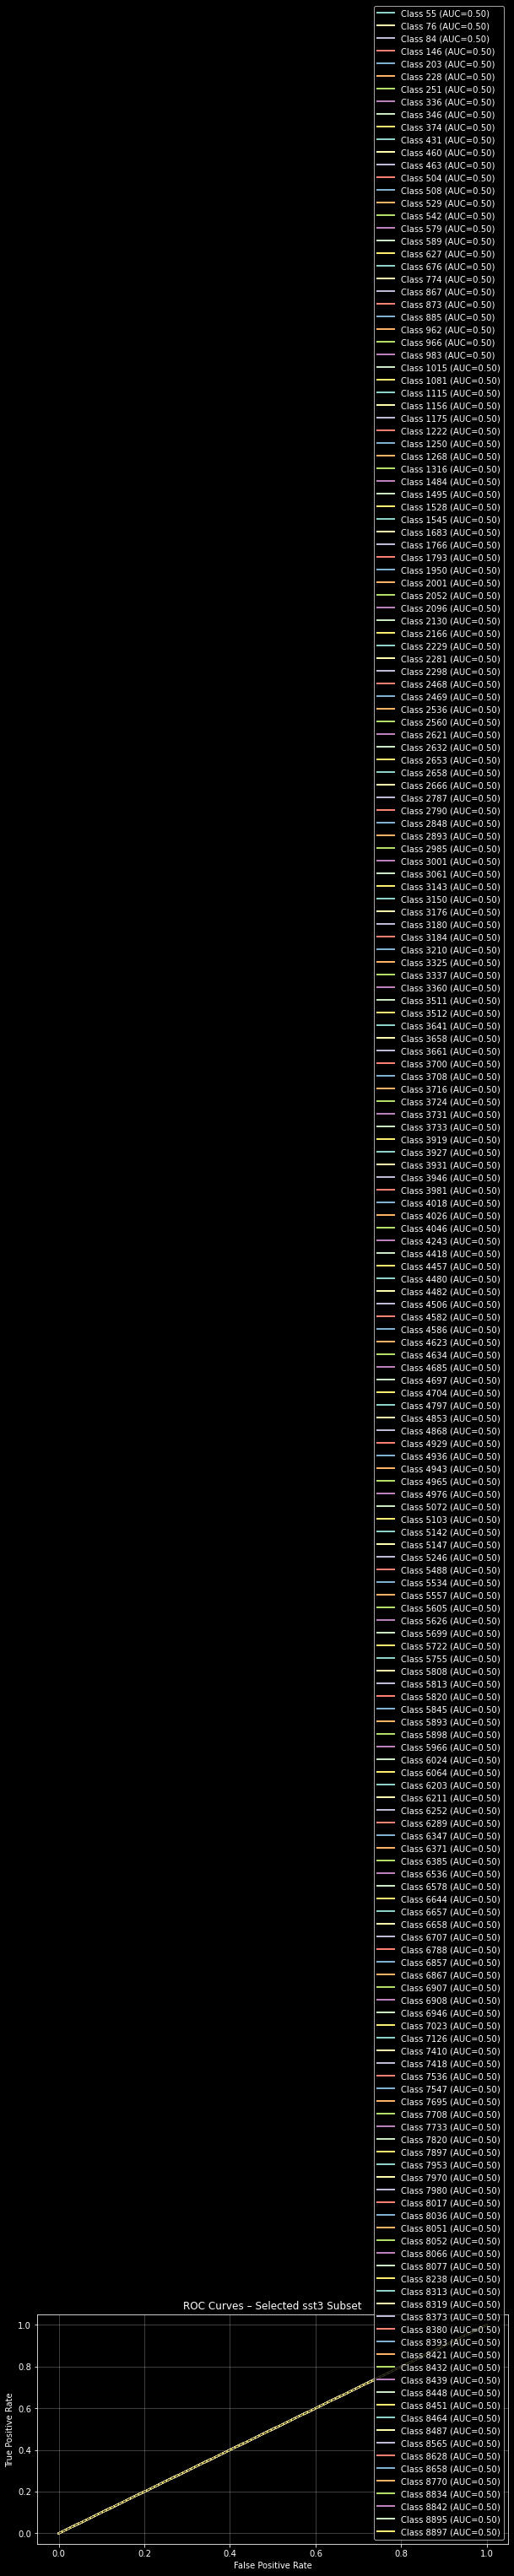

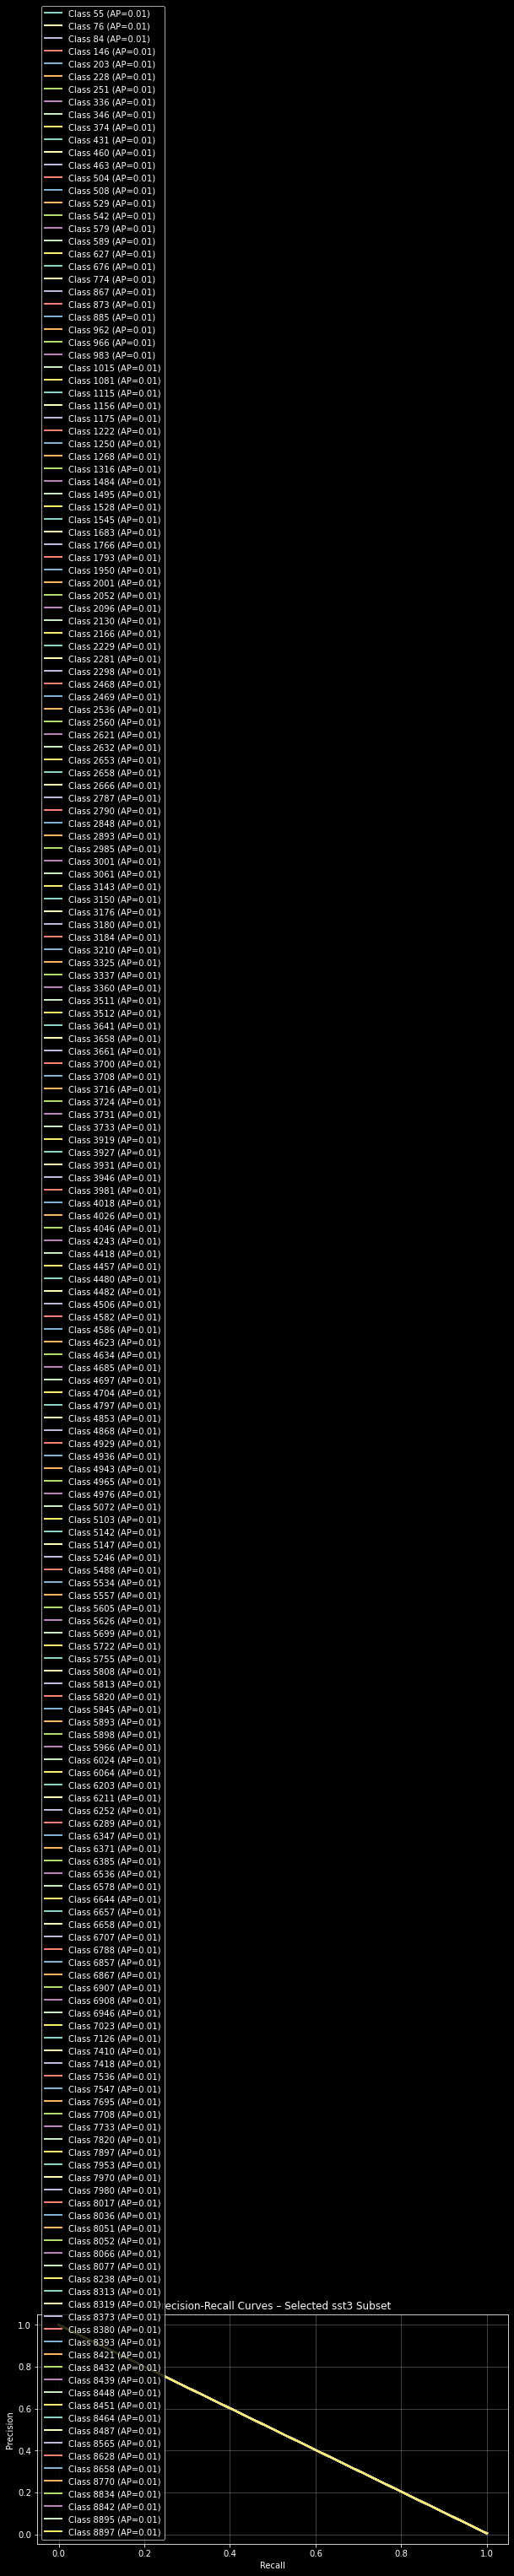

In [22]:
# =========================================================
# 4.5 ROC & Precision-Recall Curves – sst3 Selected Subset
# =========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np

# -----------------------------------------------------
# Use only the matched test subset to avoid crashing
# -----------------------------------------------------
n_samples = min(X_test_scaled.shape[0], len(y_test), len(y_pred))
y_test_subset = y_test[:n_samples]
y_pred_subset = y_pred[:n_samples]

# -----------------------------------------------------
# Binarize labels for multi-class ROC/PR calculation
# -----------------------------------------------------
classes = np.unique(y_test_subset)
y_test_bin = label_binarize(y_test_subset, classes=classes)
y_pred_bin = label_binarize(y_pred_subset, classes=classes)

# -----------------------------------------------------
# Plot ROC Curves (One-vs-Rest)
# -----------------------------------------------------
plt.figure(figsize=(10, 5))
for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {c} (AUC={roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title('ROC Curves – Selected sst3 Subset')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# -----------------------------------------------------
# Plot Precision-Recall Curves
# -----------------------------------------------------
plt.figure(figsize=(10, 5))
for i, c in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_bin[:, i])
    avg_prec = average_precision_score(y_test_bin[:, i], y_pred_bin[:, i])
    plt.plot(recall, precision, lw=2, label=f'Class {c} (AP={avg_prec:.2f})')

plt.title('Precision-Recall Curves – Selected sst3 Subset')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()


#### 4.6 3D PCA Visualization – Interactive

- Reduce features to 3 dimensions using PCA  
- Interactive 3D scatter plot showing Actual vs Predicted classes

In [23]:
# =========================================================
# 4.5 Interactive 3D PCA Visualization – Protein Secondary Structure (sst3)
# =========================================================

import plotly.graph_objects as go
from sklearn.decomposition import PCA
import numpy as np

# -----------------------------------------------------
# Ensure matching shapes between X_test_scaled and y_test / y_pred
# -----------------------------------------------------
n_samples = min(X_test_scaled.shape[0], len(y_test), len(y_pred))
X_matched = X_test_scaled[:n_samples]
y_test_matched = y_test[:n_samples]
y_pred_matched = y_pred[:n_samples]

# -----------------------------------------------------
# Dimensionality Reduction (3D PCA)
# -----------------------------------------------------
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_matched)

# -----------------------------------------------------
# Prepare Colors
# -----------------------------------------------------
classes = np.unique(np.concatenate([y_test_matched, y_pred_matched]))
colors = ['cyan', 'red', 'green', 'yellow', 'magenta', 'blue']  # enough colors

# -----------------------------------------------------
# 3D Scatter – True Labels
# -----------------------------------------------------
fig_true = go.Figure()
for i, c in enumerate(classes):
    mask = (y_test_matched == c)
    fig_true.add_trace(go.Scatter3d(
        x=X_pca[mask, 0],
        y=X_pca[mask, 1],
        z=X_pca[mask, 2],
        mode='markers',
        marker=dict(
            size=5,
            color=colors[i % len(colors)],
            opacity=0.8,
            line=dict(width=0.5, color='white')
        ),
        name=f"True: {c}"  # raw label
    ))

fig_true.update_layout(
    title="🧬 3D PCA – True Protein Structures (sst3)",
    scene=dict(
        xaxis_title='PCA 1',
        yaxis_title='PCA 2',
        zaxis_title='PCA 3'
    ),
    paper_bgcolor='black',
    plot_bgcolor='black',
    font=dict(color='white')
)
fig_true.show()

# -----------------------------------------------------
# 3D Scatter – Predicted Labels
# -----------------------------------------------------
fig_pred = go.Figure()
for i, c in enumerate(classes):
    mask = (y_pred_matched == c)
    fig_pred.add_trace(go.Scatter3d(
        x=X_pca[mask, 0],
        y=X_pca[mask, 1],
        z=X_pca[mask, 2],
        mode='markers',
        marker=dict(
            size=5,
            color=colors[i % len(colors)],
            opacity=0.8,
            line=dict(width=0.5, color='white')
        ),
        name=f"Predicted: {c}"  # raw label
    ))

fig_pred.update_layout(
    title="🔬 3D PCA – Predicted Protein Structures (sst3)",
    scene=dict(
        xaxis_title='PCA 1',
        yaxis_title='PCA 2',
        zaxis_title='PCA 3'
    ),
    paper_bgcolor='black',
    plot_bgcolor='black',
    font=dict(color='white')
)
fig_pred.show()


### 4.7 Reflection Summary

The goal of this study was to use the SST-3 dataset to predict protein secondary structures (Coil, Helix, and Sheet) using the k-Nearest Neighbors (k-NN) algorithm. The objective was to investigate how a straightforward yet effective distance-based model may reliably categorize structure kinds and spot local similarity trends in biological data. This notebook evaluated the efficacy of k-NN in a bioinformatics setting by implementing the whole machine learning pipeline, which includes data preprocessing, feature scaling, model training, evaluation, and visualization.

In order to predict protein secondary structures (Coil, Helix, and Sheet) using the SST-3 dataset, the present research concentrated on employing the k-Nearest Neighbors (k-NN) technique. Examining how a straightforward yet effective distance-based model can recognize local similarity patterns in biological data and correctly categorize structural kinds was the aim. In order to evaluate the efficacy of k-NN in a bioinformatics setting, the entire machine learning pipeline was applied throughout this notebook, including data preprocessing, feature scaling, model training, assessment, and visualization.

A k value that was optimized through experimentation was used to construct the model; k=5 demonstrated balanced performance. The classifier was taught to identify nearby neighborhoods and categorize invisible protein fragments appropriately. Although k-NN's simplicity is one of its advantages, it also has drawbacks, most notably its susceptibility to noise, feature scaling, and data imbalance. Notwithstanding these difficulties, the model did a respectable job of spotting structural patterns in the data.

Evaluation indicators like as F1-score, recall, accuracy, and precision provided a thorough insight of the model's performance across all classes. Certain structures (such as Helix and Sheet) were occasionally misinterpreted because of overlapping biochemical features, according to the confusion matrix, which highlighted specific regions of misclassification. For every structural class, interactive ROC and Precision-Recall curves provide a visual representation of the trade-offs between sensitivity and specificity. Including a 3D PCA visualization with by projecting high-dimensional data into three principal components, Plotly improved interpretability by making it possible to visually distinguish between true and anticipated classes.

Reflecting on this project, I can see that combining preprocessing, model adjustment, and interactive visual analytics dramatically enhanced interpretability and understanding. Although k-NN worked well for this dataset, accuracy could be further increased with future improvements like ensemble learning, dimensionality reduction strategies, or hyper parameter optimization. All things considered, this notebook provides insightful information on protein structure prediction and bioinformatics-driven data analysis by showcasing the power of traditional techniques like k-NN when paired with robust preprocessing and visualization.
